# Tutorial 2: Model Training for Phase Detection

In this tutorial, you'll learn how to train Convolutional Neural Networks (CNNs) to detect crystalline phases in XRD patterns.

We'll cover how to:
1. **Generate training datasets** with positive and negative examples
2. **Train detection models** for certain phases
3. **Evaluate trained models** on test patterns

In general, the key is to generate *balanced* datasets that include:

 **a) Postive examples:** patterns containing the target phase, and
 **b) Negative examples** patterns without it.

Importantly, *both* types of patterns should contain **realistic experimental artifacts.**

## Basic Setup and Imports

Let's start by importing the necessary modules for model training:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
import sys
import os

# Import galaxi modules for model training
from galaxi.core.pattern_generator import UnifiedPatternGenerator
from galaxi.core.config import XRDGenerationConfig
from galaxi import PhaseDetectionModel
from galaxi.core.config import ModelConfig
from galaxi.visualization import XRDVisualizer
from galaxi.evaluation.model_evaluator import ModelEvaluator

# Set up paths
tutorial_dir = Path(".")
cif_dir = tutorial_dir / "data" / "cif_files"
results_dir = tutorial_dir / "results" / "model_training"
results_dir.mkdir(parents=True, exist_ok=True)

print("Available CIF files for training:")
cif_files = list(cif_dir.glob("*.cif"))
for i, cif_file in enumerate(cif_files):
    print(f"  {i+1}. {cif_file.name}")
    
print(f"\nTotal: {len(cif_files)} reference phases available")

Available CIF files for training:
  1. Li3PO4_9012500.cif
  2. Li2O_108886.cif
  3. Mn2O3_159865.cif
  4. NiO_112314.cif
  5. ZrO2_2180450.cif
  6. NaNO3_2310364.cif
  7. Li2TiO3_15150.cif
  8. Co3O4_1538531.cif
  9. TiO2_121632.cif
  10. MnO_643195.cif
  11. MnF2_14142.cif
  12. LiF_18012.cif
  13. TiO2_82657.cif
  14. Li2CO3_100324.cif
  15. MnO2_643186.cif
  16. Li2MnO3_117607.cif
  17. LiMnO2_15105.cif
  18. LiMn2O4_111081.cif

Total: 18 reference phases available


## Model Training Configuration

Before training any models, we need to configure both the pattern generation and model architecture. Let's set up these configurations.

Note the below configurations are not necessarily optimized - they are just starting examples.

In [2]:
# Pattern generation configuration for training data
training_config = XRDGenerationConfig(

    # Angular range and resolution
    min_angle=10.0,
    max_angle=80.0,
    num_points=4501,
    
    # Realistic experimental variations
    uniform_shift_range=(-0.2, 0.2),              # Peak position shifts
    sample_displacement=(-0.1, 0.1),              # Sample displacement
    
    # Microstructural effects
    crystallite_size_range=(5.0, 100.0),          # Wide range of crystallite sizes
    microstrain_range=(0.0, 0.004),               # Microstrain for peak broadening
    lattice_strain_range=(0.0, 0.02),             # Lattice strain effects
    
    # Temperature effects
    temperature_range=(200, 600),                 # Temperature range (K)
    atomic_displacement_range=(0.01, 0.05),       # Atomic displacement parameters
    
    # Texture and orientation
    texture_range=(0.4, 1.6),                     # Strong preferred orientation effects
    
    # Background, noise, and amorphous signal
    background_level=(0.5, 8.0),                  # Variable background
    noise_level=(0.1, 0.25),                      # Realistic noise levels
    diffuse_scattering_intensity=(0.0, 15.0),     # Diffuse scattering
    amorphous_intensity=(0.0, 25.0),              # Amorphous content
    
    # Include minor impurities in training
    enable_impurities=True,                       # Add random peaks
    impurity_intensity_range=(0.0, 10.0)          # 0-10% max peak intensity
)

# Model configuration for binary phase detection
# from_xrd_config() copies num_points/min_angle/max_angle across from the
# generation config. Constructing ModelConfig() bare instead leaves the
# model on its 7001-point 5-105 deg defaults while the patterns above are
# 4501 points over 10-80 deg -- which does not raise, it just silently
# resamples every pattern onto the wrong grid.
model_config = ModelConfig.from_xrd_config(
    training_config,
    # Training parameters
    num_epochs=10,                                # Training epochs
    learning_rate=0.001,                          # Learning rate
    batch_size=32,                                # Batch size
    
    # Model architecture
    conv_channels=[32, 64, 128],                  # CNN channels
    conv_kernels=[16, 12, 8],                     # Kernel sizes
    fc_sizes=[1024, 512, 128],                    # Fully connected layers
    dropout_rate=0.4,                             # Dropout for regularization
    
    # Model behavior
    activation="relu",                            # Activation function
    use_batch_norm=True,                          # Batch normalization
    model_config="detection",                     # Optimized for detection
    
    # Output options
    save_models=True,                             # Save trained models
    save_plots=True                               # Save training curves
)

print("Training Configuration:")
print(f"  Pattern generation: {training_config.min_angle}° to {training_config.max_angle}°")
print(f"  Crystallite size range: {training_config.crystallite_size_range} nm")
print(f"  Background level: {training_config.background_level}")
print(f"  Texture range: {training_config.texture_range}")
print(f"\nModel Configuration:")
print(f"  Epochs: {model_config.num_epochs}")
print(f"  Learning rate: {model_config.learning_rate}")
print(f"  Architecture: {model_config.conv_channels} conv → {model_config.fc_sizes} fc")
print(f"  Dropout rate: {model_config.dropout_rate}")

Training Configuration:
  Pattern generation: 10.0° to 80.0°
  Crystallite size range: (5.0, 100.0) nm
  Background level: (0.5, 8.0)
  Texture range: (0.4, 1.6)

Model Configuration:
  Epochs: 10
  Learning rate: 0.001
  Architecture: [32, 64, 128] conv → [1024, 512, 128] fc
  Dropout rate: 0.4


## Single Reference Phase Model Training

Let's start by training a detection model for a single reference phase. This involves:

1. **Generating positive examples**: Patterns containing the target phase (pure or in mixtures)
2. **Generating negative examples**: Patterns without the target phase
3. **Training a binary classifier**: To distinguish presence vs. absence of the target phase

### Step 1: Generate Training Dataset for Single Phase

In [3]:
# Select a target phase for training
target_phase_file = cif_dir / "TiO2_121632.cif"
target_phase_name = target_phase_file.stem

print(f"Training binary detection model for: {target_phase_name}")
print(f"Using CIF file: {target_phase_file.name}")

# Initialize pattern generator
generator = UnifiedPatternGenerator(reference_dir=str(cif_dir), config=training_config)

# Generate training dataset with positive and negative examples
print("\nGenerating training patterns...")
print("This may take several minutes.")

# Below we generate training data - 400 patterns in total
# In practice, we will probably need to generate many more than this!
# Remember, neural networks are data-hungry...
training_patterns = generator.generate_phase_detection_patterns(
    target_phase_name=target_phase_name,           # Phase to detect
    num_positive=200,                              # Positive examples (with target phase)
    num_negative=200,                              # Negative examples (without target phase)
    target_fraction_range=(0.1, 1.0),              # Target phase concentration range
    save_patterns=True,                            # Save patterns to files
    output_dir=str(results_dir / f"training_data_{target_phase_name}"),
    # npy is the format train_detection() reads back off disk: a (2, N) array
    # holding the normalized intensity and its peak mask. Writing "xy" here
    # produces raw (2theta, intensity) columns that training rejects.
    file_format="npy"
)

print(f"\nGenerated {len(training_patterns['positive'])} positive examples")
print(f"Generated {len(training_patterns['negative'])} negative examples")
print(f"Training data saved to: {results_dir / f'training_data_{target_phase_name}'}")

Training binary detection model for: TiO2_121632
Using CIF file: TiO2_121632.cif
Discovered 18 reference phases (structures will be lazily loaded)

Generating training patterns...
This may take several minutes.


COD structure loading: 449 loaded, 47 filtered, 504 errors from 1000 attempted
Generating phase detection patterns for target: TiO2_121632
Positive examples: 200, Negative examples: 200
Target fraction range: (0.1, 1.0)
Available COD structures: 449


Saved detection patterns to results/model_training/training_data_TiO2_121632
Detection ground truth saved to results/model_training/training_data_TiO2_121632/detection_ground_truth.json
Generated 200 positive and 200 negative patterns

Generated 200 positive examples
Generated 200 negative examples
Training data saved to: results/model_training/training_data_TiO2_121632


### Step 2: Visualize Training Examples

Let's examine some positive and negative examples to understand what the model will learn:

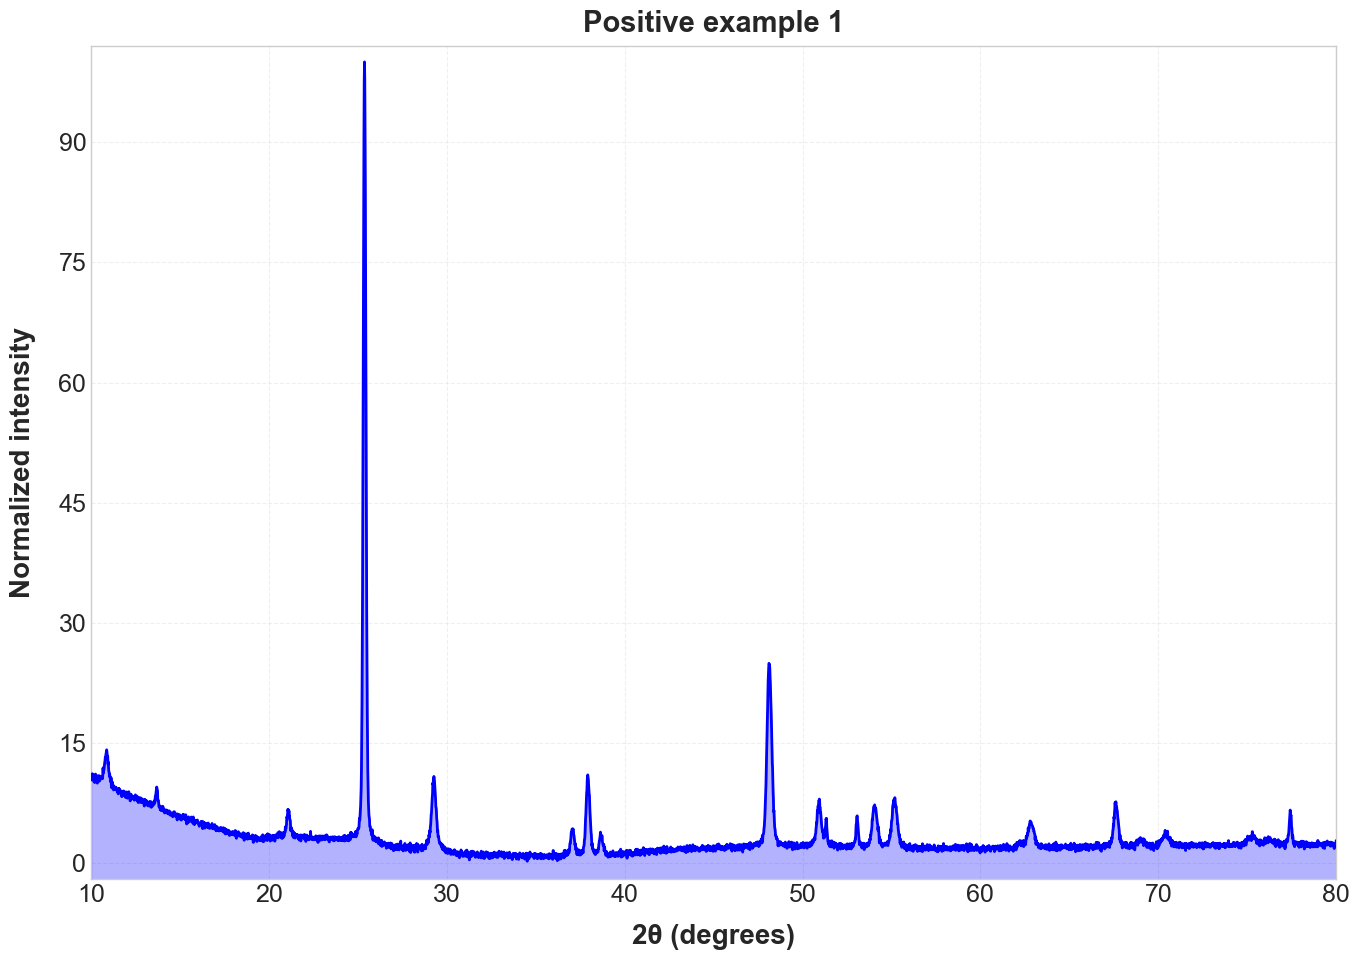

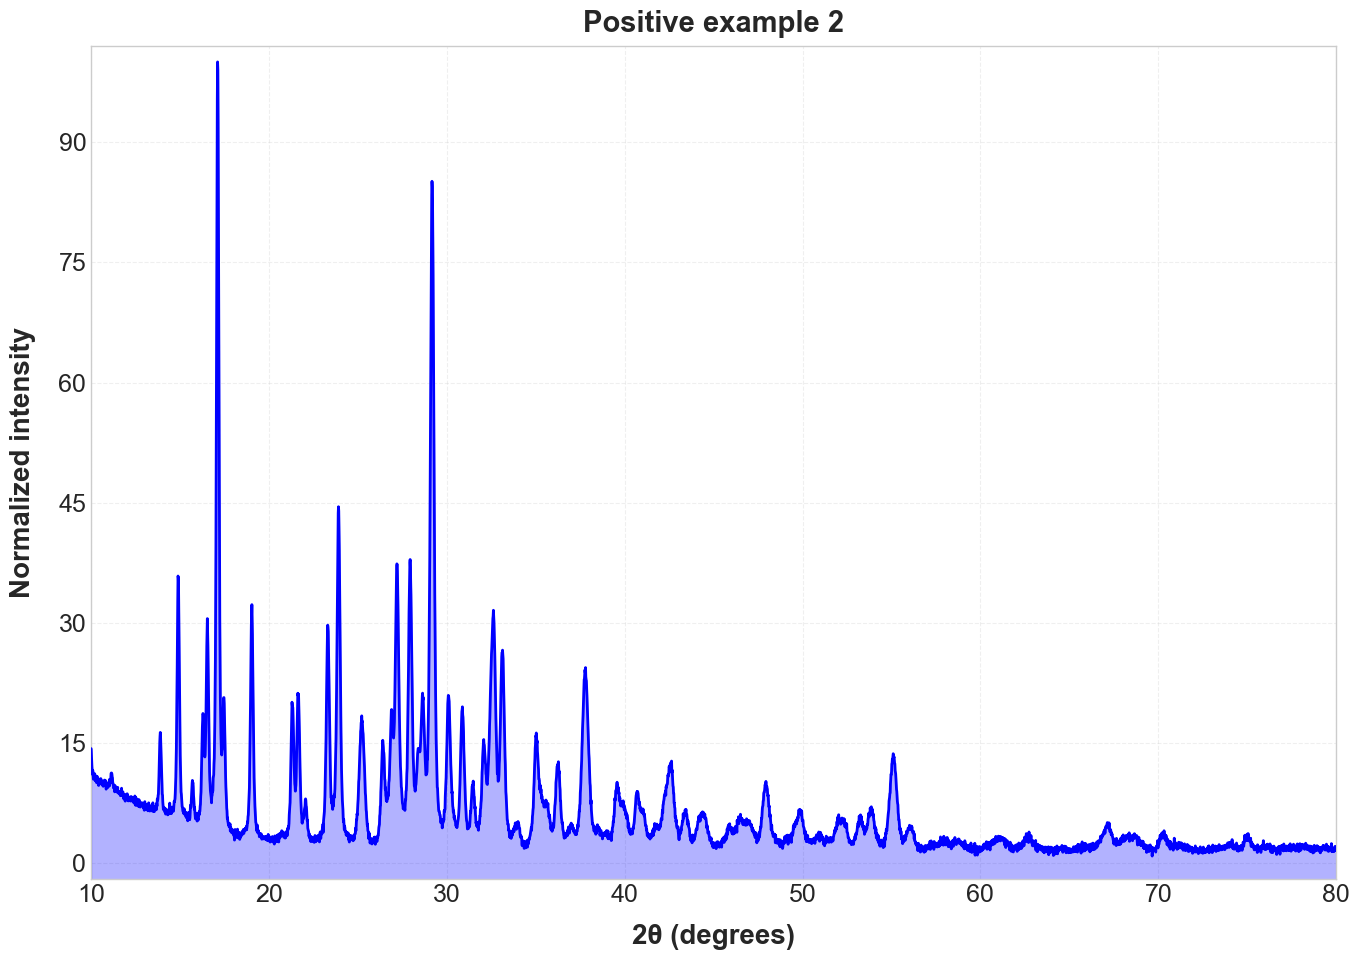

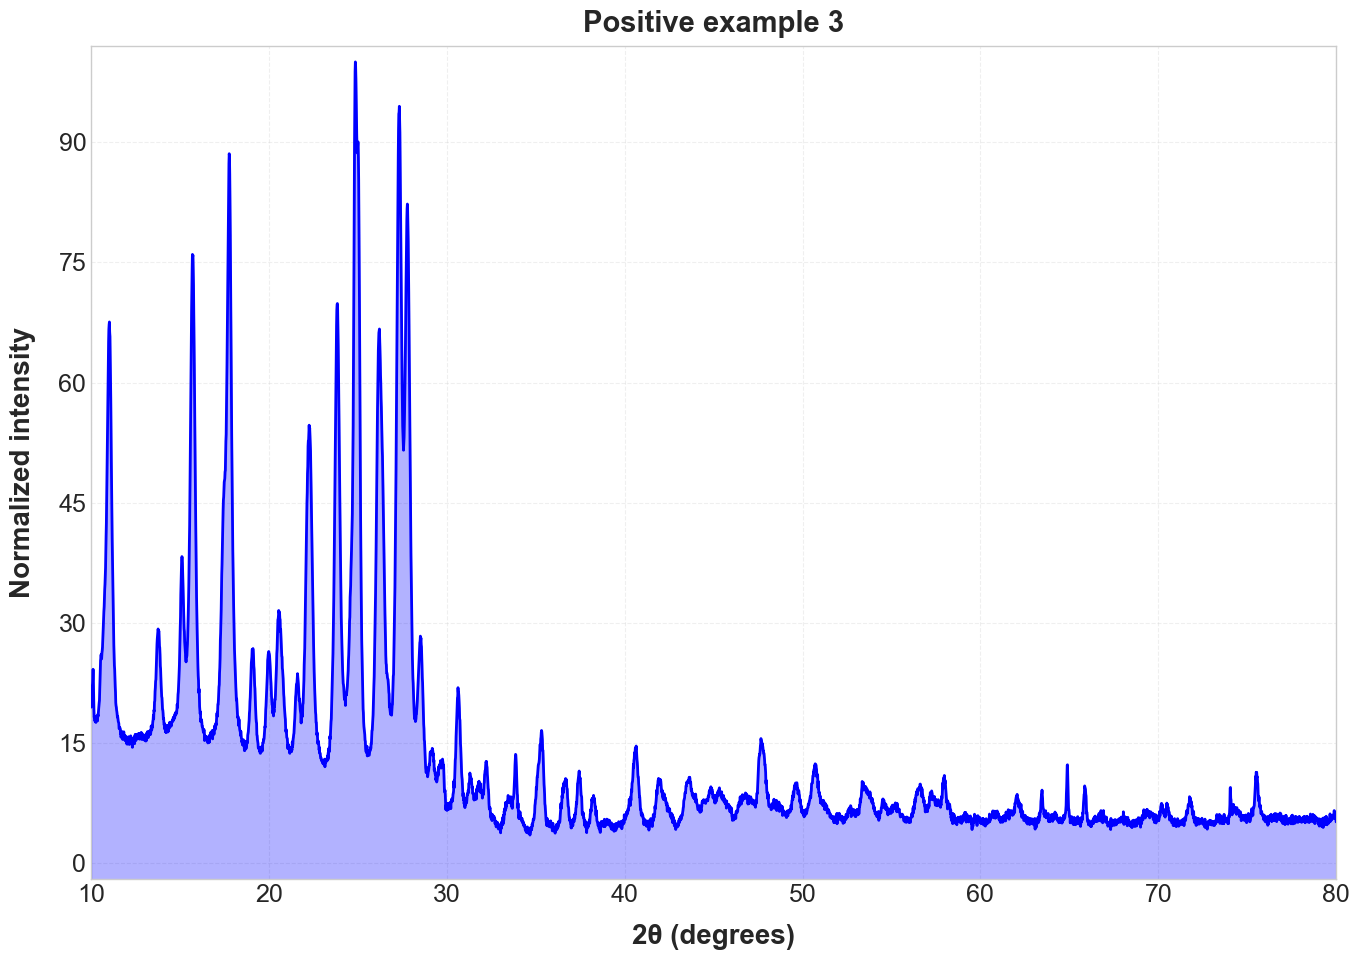

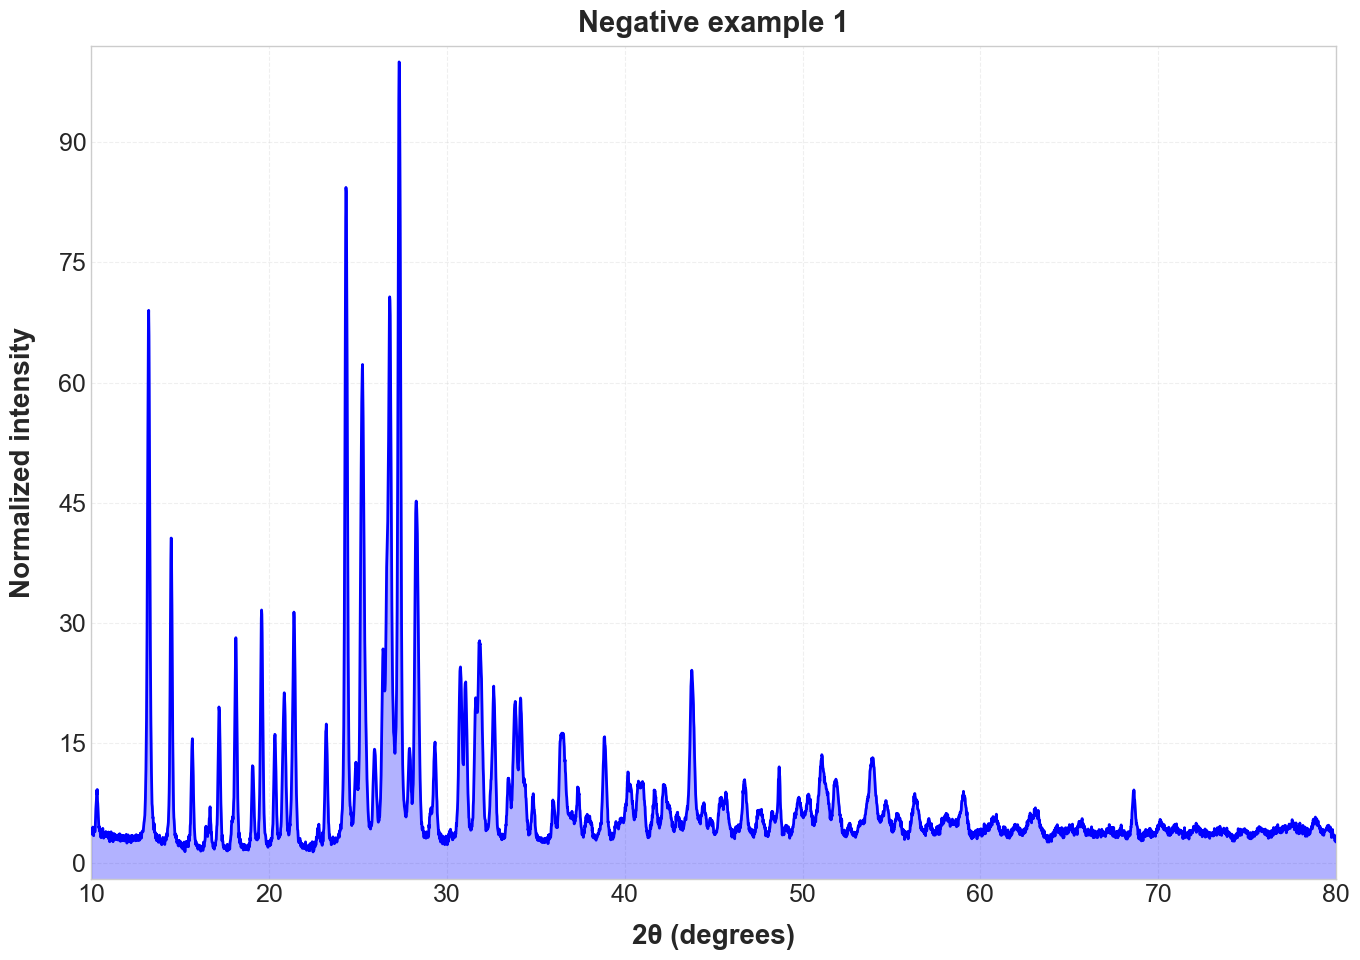

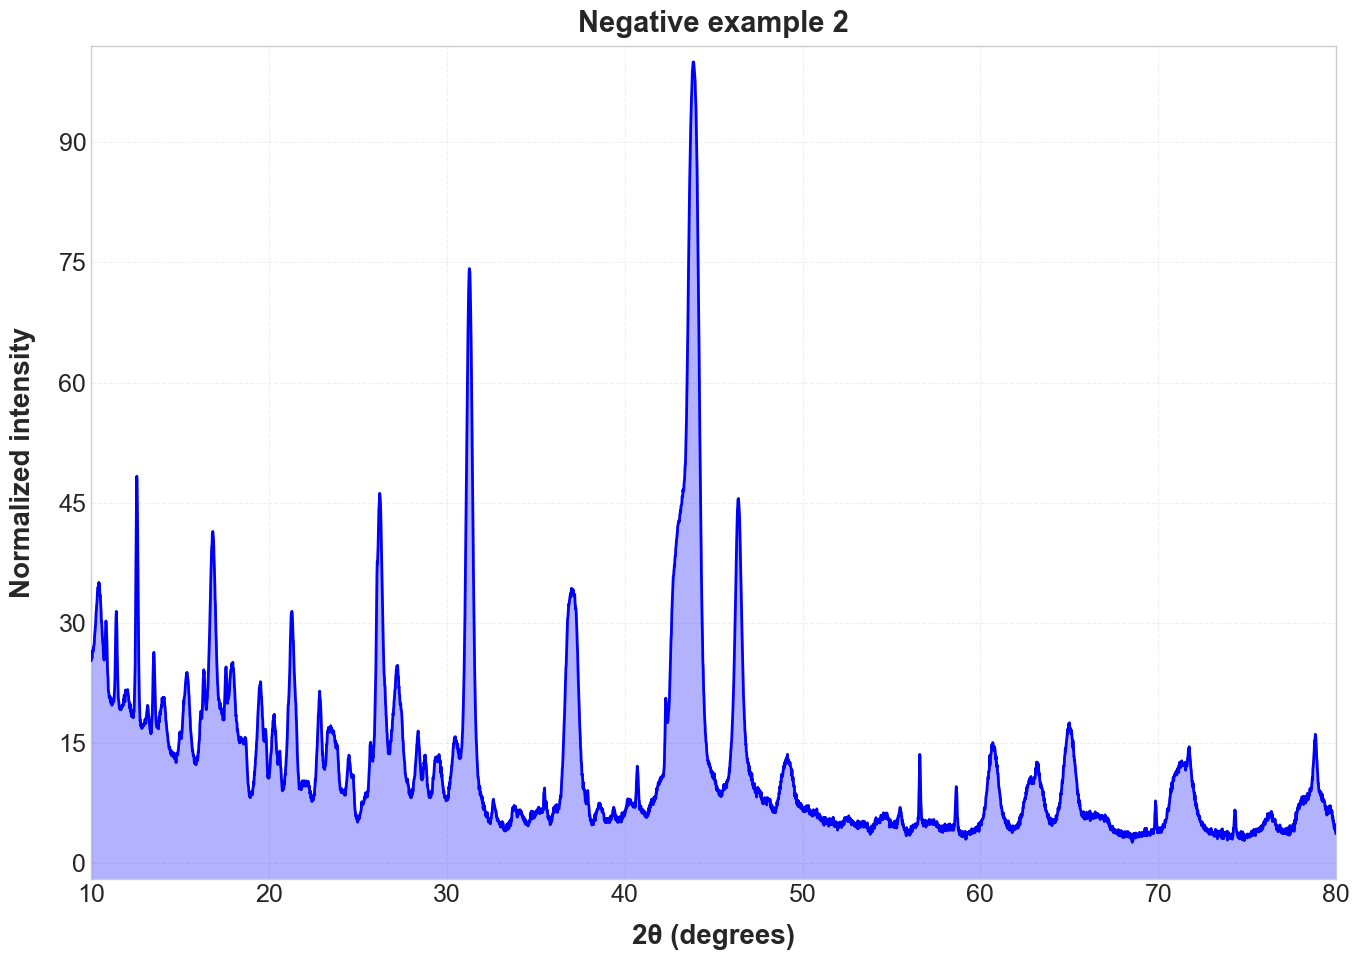

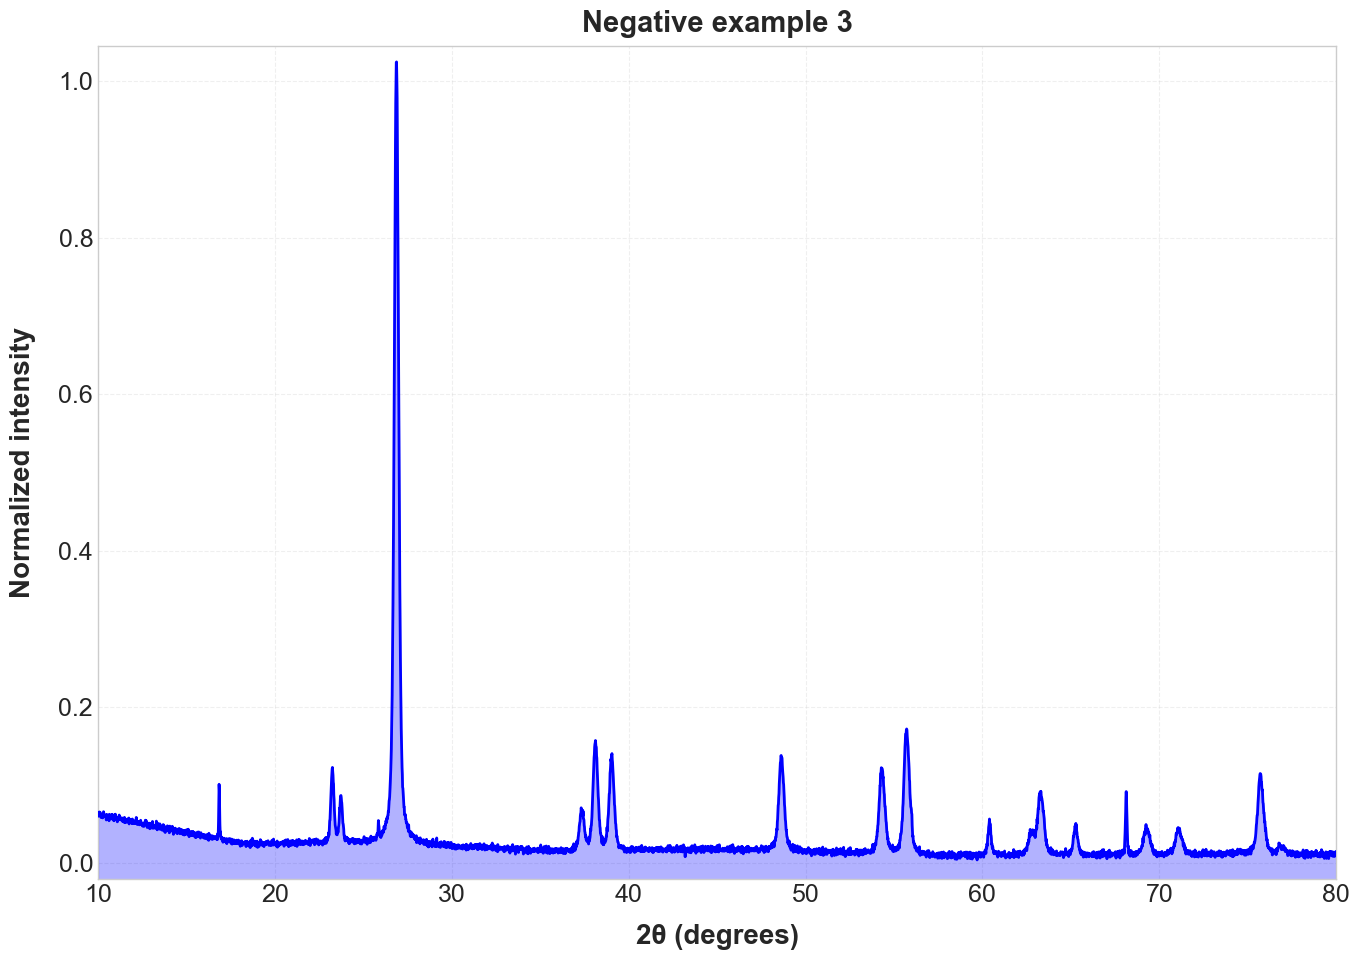

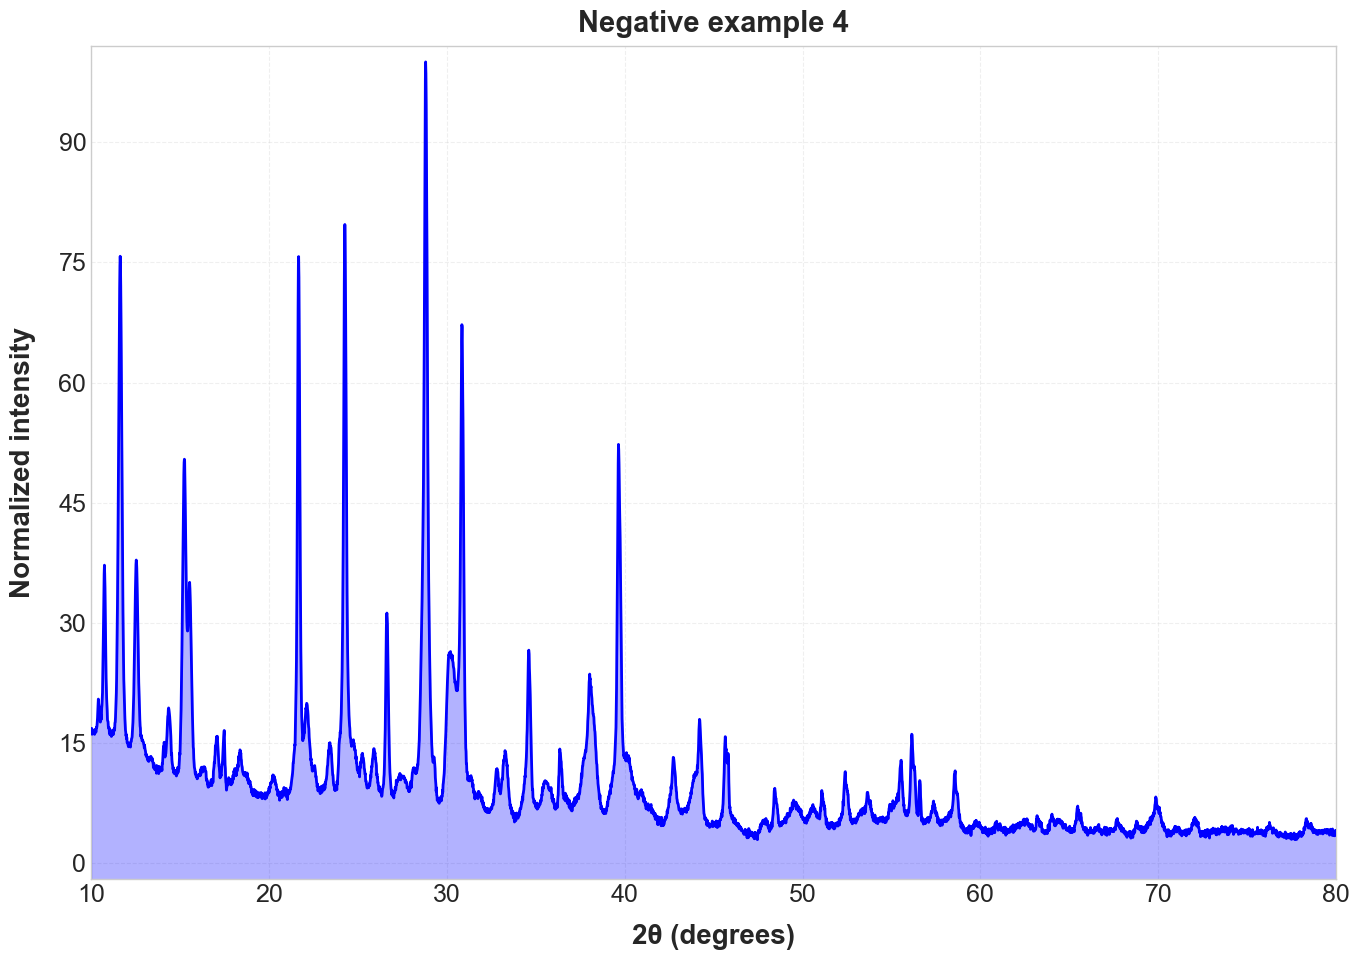

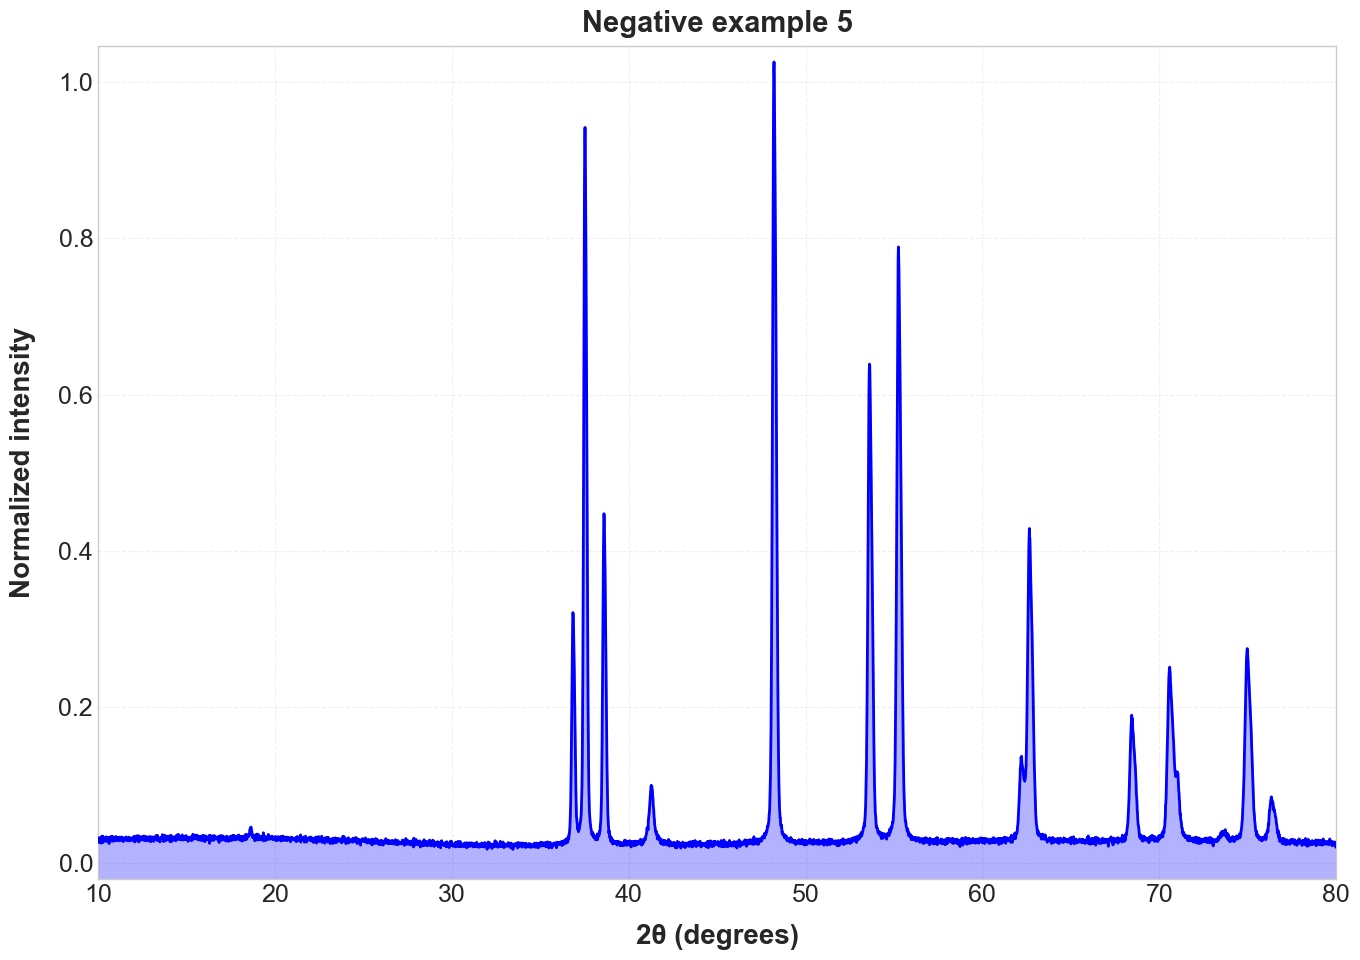

In [4]:
# Create visualizer
visualizer = XRDVisualizer(figsize=(14, 10))

# The saved training patterns are .npy arrays holding intensities only -- they
# carry no angle axis, so rebuild it from the generation config.
two_theta = np.linspace(
    training_config.min_angle, training_config.max_angle, training_config.num_points
)


def load_training_pattern(path):
    """Return the intensity trace stored in one saved training pattern.

    generate_phase_detection_patterns() writes a 1-D (N,) intensity trace, while
    StreamlinedWorkflow's own generator writes (2, N) with a peak mask on row 1.
    Accept either.
    """
    arr = np.load(path)
    return arr[0] if arr.ndim == 2 else arr


data_dir = results_dir / f"training_data_{target_phase_name}"

# Path to folder with generated patterns (positive examples)
pos_pattern_path = data_dir / "positive"

for i, fname in enumerate(sorted(os.listdir(pos_pattern_path))[:3]):
    intensity = load_training_pattern(pos_pattern_path / fname)

    fig, ax = visualizer.plot_pattern(
      x_values=two_theta,
      intensity=intensity,
      title=f"Positive example {i+1}",
      xlabel="2\u03b8 (degrees)",
      ylabel="Normalized intensity",
      color='blue',
      save=False,
      show=True
    )

# Load the ground truth metadata to get pattern types
with open(data_dir / "detection_ground_truth.json", 'r') as f:
    ground_truth = json.load(f)

# Path to folder with generated patterns (negative examples)
neg_pattern_path = data_dir / "negative"

for i, fname in enumerate(sorted(os.listdir(neg_pattern_path))[:5]):
    intensity = load_training_pattern(neg_pattern_path / fname)

    # Get the pattern type from metadata to create descriptive title
    pattern_key = fname  # The filename should match the key in ground truth
    if pattern_key in ground_truth:
        pattern_type = ground_truth[pattern_key].get("pattern_type", "unknown")
        if pattern_type == "background_only":
            title = f"Negative example {i+1}: target not present in mixture"
        elif pattern_type == "perturbed_target":
            title = f"Negative example {i+1}: unphysical peak changes"
        else:
            title = f"Negative example {i+1}: {pattern_type}"
    else:
        title = f"Negative example {i+1}"

    fig, ax = visualizer.plot_pattern(
      x_values=two_theta,
      intensity=intensity,
      title=title,
      xlabel="2\u03b8 (degrees)",
      ylabel="Normalized intensity",
      color='blue',
      save=False,
      show=True
    )


Notice these are quite messy and difficult to interpret...which is good! These are the challenging types of cases that we want our models to learn from. The question is whether they can identify the correlation between each phase and its presence (or absence) of peaks in these messy-looking patterns.

### Step 3: Train Binary Detection Model

Now we'll train a CNN model to distinguish between positive and negative examples:

In [5]:
# Initialize the detection model. reference_dir lets save_peak_list() write a
# real reference peak list alongside the weights instead of an empty one.
detection_model = PhaseDetectionModel(
    target_phase=target_phase_name,
    reference_dir=str(cif_dir),
    config=model_config,
)

# train_detection() reads the patterns straight from the directory that
# generate_phase_detection_patterns() wrote above, and infers labels from its
# positive/ and negative/ subfolders -- so no manual label arrays are needed.
training_results = detection_model.train_detection(
    generation_output_dir=results_dir / f"training_data_{target_phase_name}",
    model_output_dir=str(results_dir / f"models_{target_phase_name}"),
    test_size=0.2,                                 # 20% for testing
    val_size=0.2                                   # 20% for validation
)

print(f"\nTraining completed!")
print(f"Final Results:")
print(f"  Training Accuracy: {training_results['train']['train_accuracy']:.4f}")
print(f"  Validation Accuracy: {training_results['validation']['val_accuracy']:.4f}")
print(f"  Test Accuracy: {training_results['test']['test_accuracy']:.4f}")
print(f"  Test AUC: {training_results['test']['test_auc']:.4f}")
print(f"\nModel saved to: {results_dir / f'models_{target_phase_name}'}")


Discovered 18 reference phases (structures will be lazily loaded)
Training set: 240 samples
Validation set: 80 samples
Test set: 80 samples


Starting training...


Epoch  1/10: Train Loss: 0.6276, Val Loss: 1.2715, Val Acc: 0.6875


Epoch  2/10: Train Loss: 0.2877, Val Loss: 0.4933, Val Acc: 0.7750


Epoch  3/10: Train Loss: 0.2453, Val Loss: 0.4323, Val Acc: 0.8000


...

Epoch  6/10: Train Loss: 0.1045, Val Loss: 0.5161, Val Acc: 0.7750


Epoch  7/10: Train Loss: 0.0532, Val Loss: 0.7373, Val Acc: 0.5500


Early stopping at epoch 8/10


Final Test Accuracy: 0.7125
Final Test AUC: 0.9784
Final Test Log Loss: 0.4287



Training completed!
Final Results:
  Training Accuracy: 1.0000
  Validation Accuracy: 0.5625
  Test Accuracy: 0.7125
  Test AUC: 0.9784

Model saved to: results/model_training/models_TiO2_121632



Now let's take a look at the results from training by opening some of the png files that were saved locally:
- results/model_training/models_TiO2_121632/training_plots_TiO2_121632.png: shows the training and validation losses
- results/model_training/models_TiO2_121632/roc_curve_TiO2_121632.png: shows the ROC curve

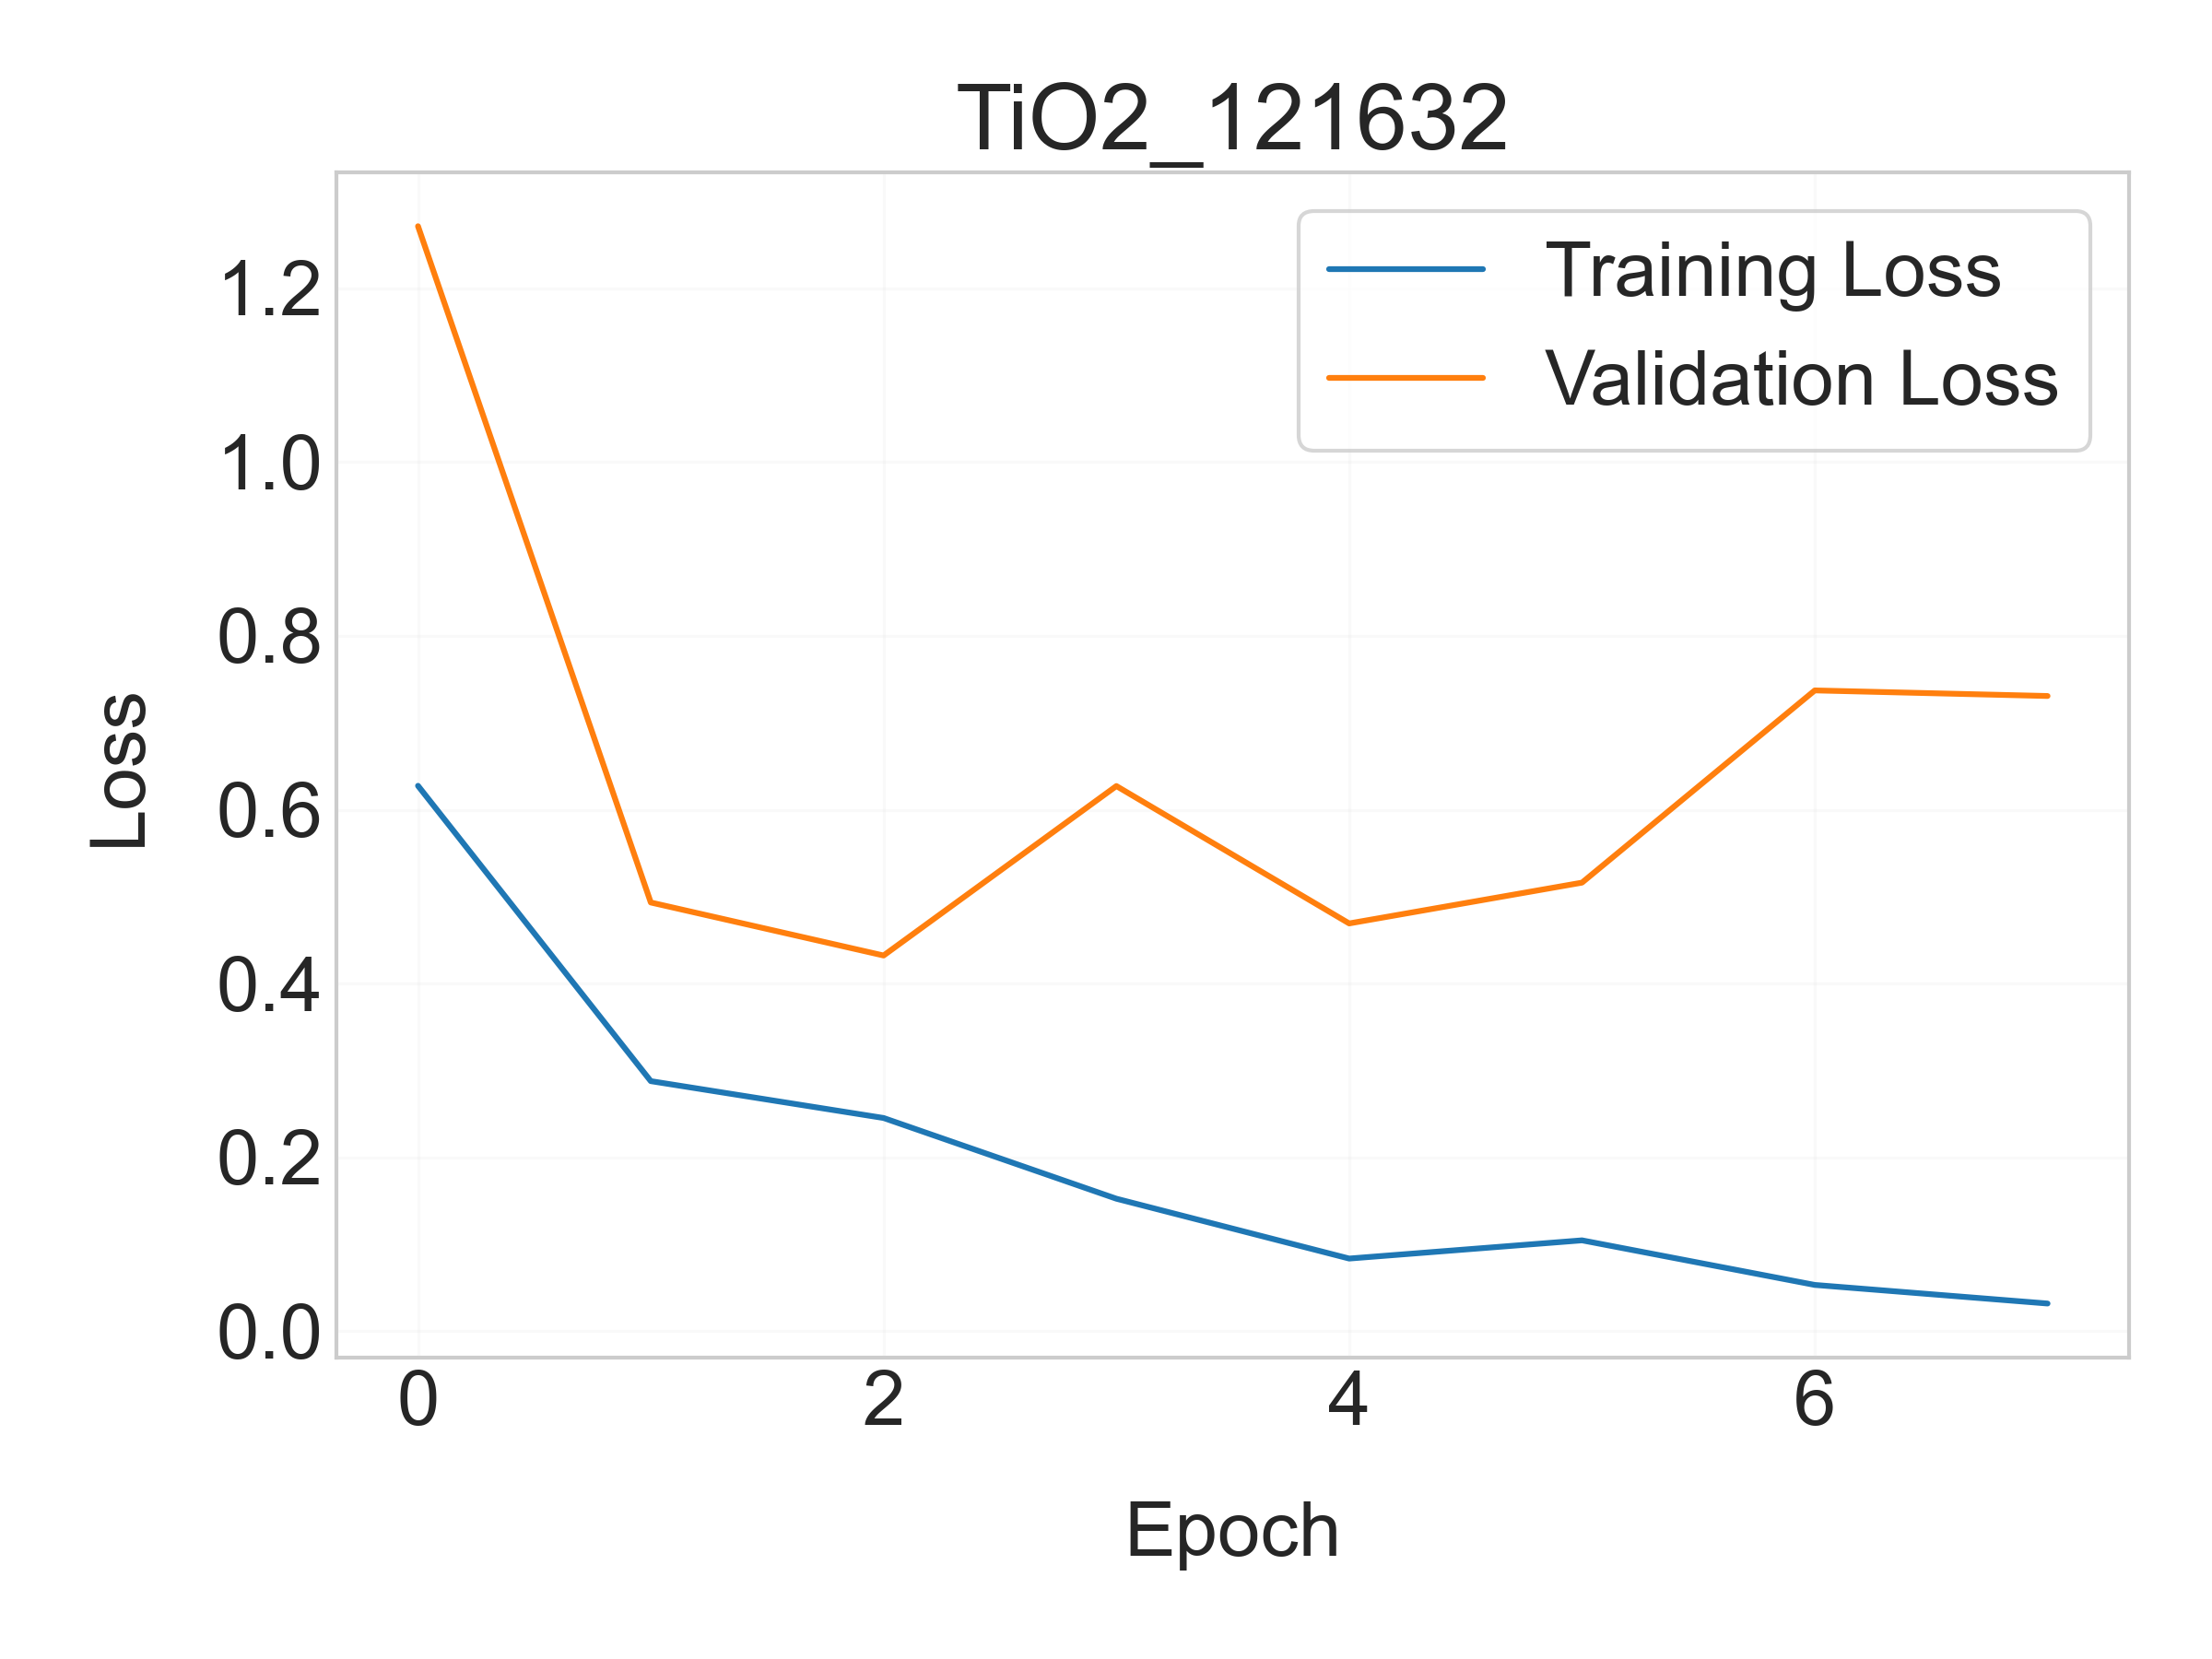

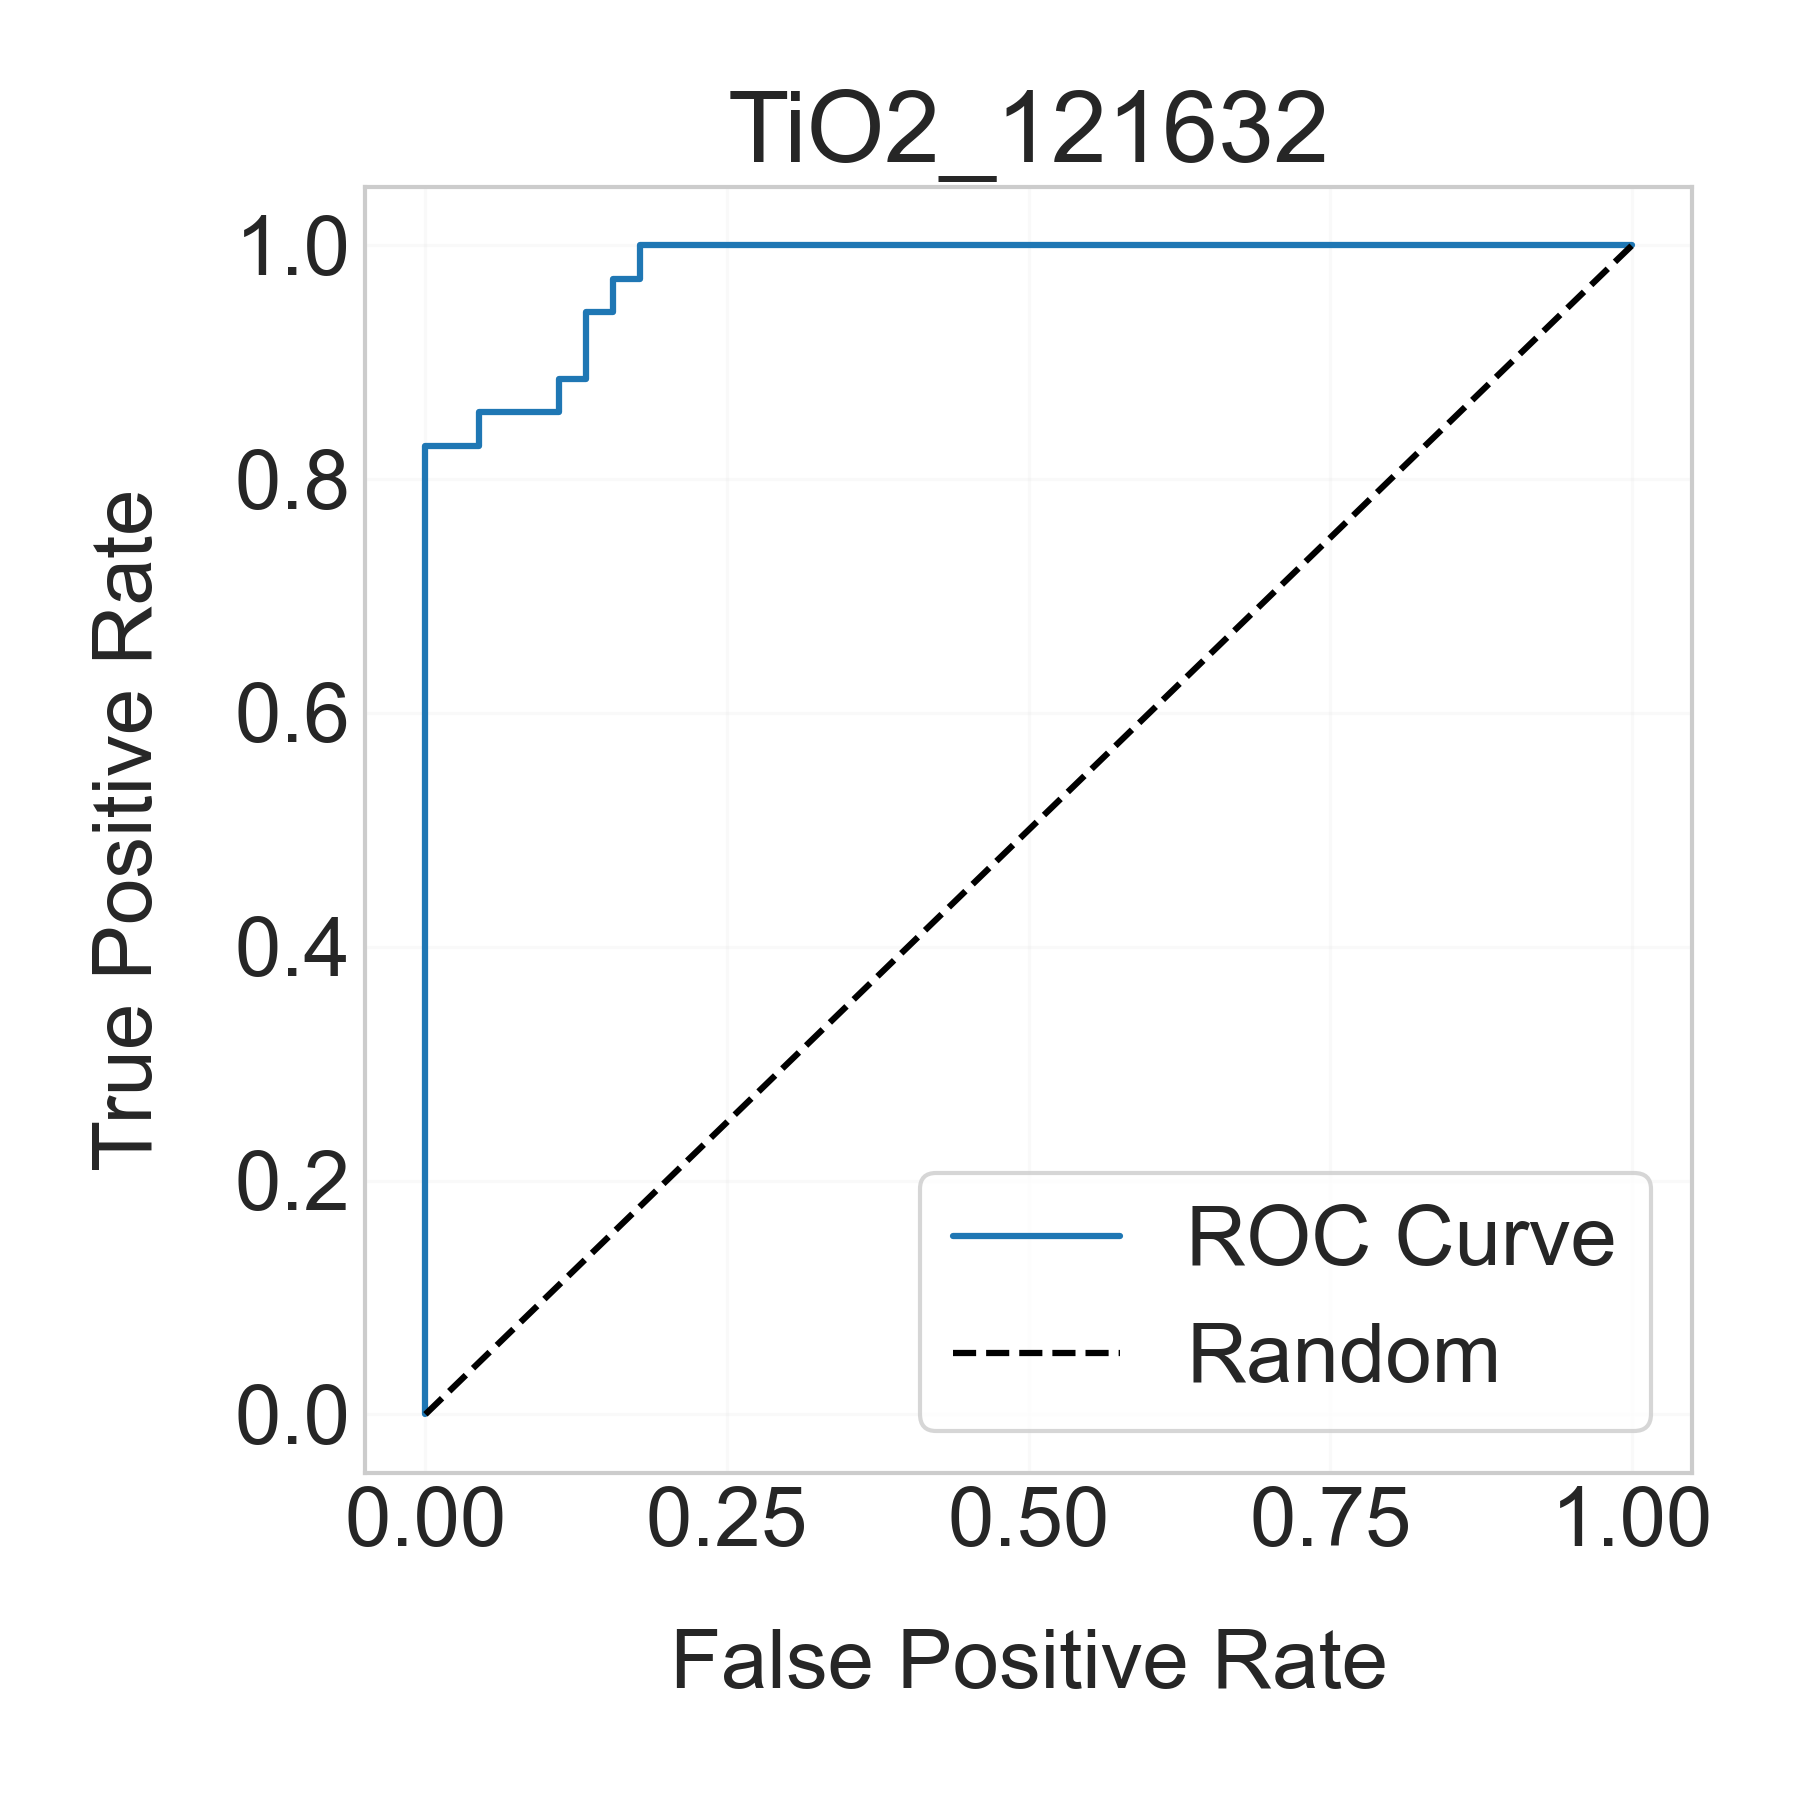

In [6]:
from IPython.display import Image, display

# Display both plots
display(Image(results_dir / f'models_{target_phase_name}' / f'training_plots_{target_phase_name}.png', width=600))
display(Image(results_dir / f'models_{target_phase_name}' / f'roc_curve_{target_phase_name}.png', width=600))


Notice that the validation loss quickly diverges from the training loss. This tells us that the model is **overfitting**. We want to avoid this by:
- Generating more patterns on which to train the model. This is the best solution, though it will require more compute time.
- Increasing the dropout rate in the CNN. This is a hyperparameter that needs to be carefully optimized.
- Using fewer epochs (early stopping). The idea is to find the number of epochs that leads to the best validation accuracy.

### Step 4: Test the Trained Model

Let's test our trained model on some new patterns to see how well it performs:

Generating test patterns for model evaluation...

Model Predictions:
  Pure TiO2_121632 (should be > 0.5): 0.1814
  Pure Li3PO4_9012500 (should be < 0.5): 0.1901
  30% TiO2_121632 + 70% Li3PO4_9012500 (should be > 0.5): 0.1800


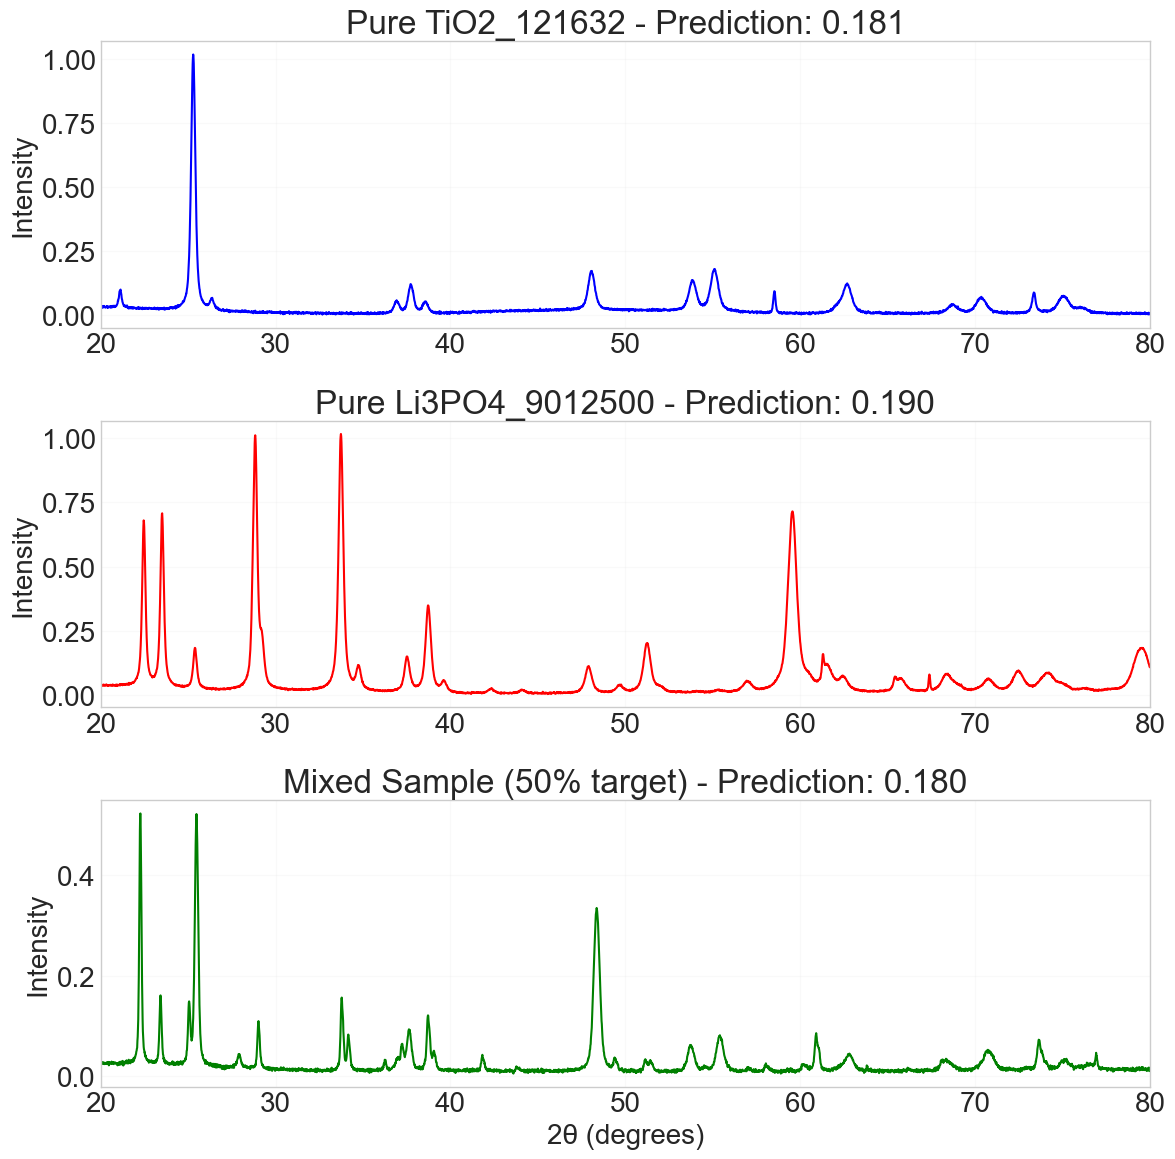

In [7]:
# Generate some test patterns for evaluation
print("Generating test patterns for model evaluation...")

# Generate known positive test case (pure target phase)
test_positive = generator.generate_single_phase_pattern(
    cif_file=str(target_phase_file),
    target_concentration=1.0
)

# Generate known negative test case (different phase)
other_phase_file = [f for f in cif_files if f != target_phase_file][0]
test_negative = generator.generate_single_phase_pattern(
    cif_file=str(other_phase_file),
    target_concentration=1.0
)

# Generate mixed test case (target phase + other phases)
test_mixed = generator.generate_multi_phase_pattern(
    cif_files=[str(target_phase_file), str(other_phase_file)],
    concentrations=[0.5, 0.5]  # 50% target phase, 50% other
)

# Make predictions
prob_positive = detection_model.predict(test_positive['intensity'])
prob_negative = detection_model.predict(test_negative['intensity'])
prob_mixed = detection_model.predict(test_mixed['intensity'])

print(f"\nModel Predictions:")
print(f"  Pure {target_phase_name} (should be > 0.5): {prob_positive:.4f}")
print(f"  Pure {other_phase_file.stem} (should be < 0.5): {prob_negative:.4f}")
print(f"  30% {target_phase_name} + 70% {other_phase_file.stem} (should be > 0.5): {prob_mixed:.4f}")

# Visualize predictions
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

# Plot test patterns with predictions
ax1.plot(test_positive['two_theta'], test_positive['intensity'], 'b-', linewidth=1.5)
ax1.set_title(f"Pure {target_phase_name} - Prediction: {prob_positive:.3f}")
ax1.set_ylabel("Intensity")
ax1.grid(True, alpha=0.1)

ax2.plot(test_negative['two_theta'], test_negative['intensity'], 'r-', linewidth=1.5)
ax2.set_title(f"Pure {other_phase_file.stem} - Prediction: {prob_negative:.3f}")
ax2.set_ylabel("Intensity")
ax2.grid(True, alpha=0.1)

ax3.plot(test_mixed['two_theta'], test_mixed['intensity'], 'g-', linewidth=1.5)
ax3.set_title(f"Mixed Sample (50% target) - Prediction: {prob_mixed:.3f}")
ax3.set_xlabel("2θ (degrees)")
ax3.set_ylabel("Intensity")
ax3.grid(True, alpha=0.1)

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(20, 80)

plt.tight_layout()
plt.savefig(results_dir / f"model_predictions_{target_phase_name}.png", dpi=300, bbox_inches='tight')
plt.show()

To improve accuracy you will need to generate more training data and optimize the model architecture.

Before tuning, though, it is worth testing more comprehensively than a single held-out split.
`StreamlinedWorkflow.step_4_generate_comprehensive_test_data` builds a synthetic test set that
isolates individual artifacts — strain, texture, sample displacement, impurity fractions — and
`step_5_evaluate_models` scores a trained model against each of them separately, which shows
*which* physical effects a model is weak to rather than just how it does on average.